#### Reto: "Predicción de Fallos en Equipos en Plantas Energéticas a 15 días vista"

Objetivo del Reto:

Evolucionar la solución para desarrollar un modelo analítico predictivo que permita anticipar fallos a 15 días vista en los equipos de la planta energética con una ***precisión mínima del 80% (accuracy ≥ 0.80) y por lo menos un 0.75 de f1.***

Por un lado se quiere predecir las horas operativas que tendrá un equipo en los próximos 15 días, de cara a considerar su mantenimiento conforme a las horas recomendadas de revisión.

Por otro lado, se quiere evaluar si una máquina fallará en los próximos 15 días, con un 80% de fiabilidad.

Evalúa la robustés del modelo en el tiempo.

Para lograr esto, deberéis:

Mezclar y preprocesar los datos de los 3 datasets proporcionados, teniendo en cuenta la componente temporal.

Seleccionar variables relevantes y generar nuevas características si es necesario. Considera usar PCA para reducir dimensiones (conservando 95% de la varianza).

Construir y evaluar múltiples modelos predictivos, que inclyan forecasting y comparando su rendimiento.

Ajustar hiperparámetros y optimizar el modelo para alcanzar la precisión deseada.

Documentar los hallazgos y justificar la elección del mejor modelo.

Bonus 1: Encontrar patrones de fallos

Usa K-Means o DBSCAN para agrupar los equipos según sus condiciones operativas y comportamiento previo a los fallos.

Incluye las siguientes características para el clustering:

Promedio de temperatura y vibración por equipo.

Desviación estándar de temperatura y vibración.

Horas operativas acumuladas promedio.

Visualiza los clusters utilizando gráficos de dispersión o mapas de calor.

Interpreta los resultados: ¿Qué patrones emergen? ¿Hay grupos de equipos más propensos a fallar?


In [46]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

from typing import Tuple
from sklearn.base import RegressorMixin
from typing import Tuple, List
from sklearn.pipeline import Pipeline
from sklearn.base import RegressorMixin
from typing import Optional
from sklearn.base import ClassifierMixin

from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from typing import Tuple, List, Dict
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

from sklearn.pipeline import make_pipeline
import optuna.visualization as vis
from statsmodels.tsa.arima.model import ARIMA


from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../data/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../data/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../data/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())


### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_C,Modelo_6,173,913
1,2,Compresor,Fabricante_B,Modelo_3,495,550
2,3,Generador,Fabricante_B,Modelo_2,478,542
3,4,Motor,Fabricante_A,Modelo_7,373,637
4,5,Generador,Fabricante_B,Modelo_9,171,748


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,1,2021-01-09,Correctivo,3992,20,Ubicacion_C
1,2,1,2021-01-20,Correctivo,1689,21,Ubicacion_C
2,3,1,2021-02-02,Correctivo,2787,7,Ubicacion_C
3,4,1,2021-02-14,Correctivo,2857,9,Ubicacion_C
4,5,1,2021-02-15,Correctivo,2421,2,Ubicacion_C


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,34.749896,2.136812,614
1,2,1,2021-01-02,89.588937,9.409404,634
2,3,1,2021-01-03,56.200558,1.529395,658
3,4,1,2021-01-04,70.555608,3.411009,664
4,5,1,2021-01-05,97.509000,0.618757,683


In [4]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")

### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61726 entries, 0 to 61725
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             61726 non-null  int64 
 1   ID_Equipo            61726 non-null  int64 
 2   Fecha                61726 non-null  object
 3   Tipo_Mantenimiento   61726 non-null  object
 4   Costo_Mantenimiento  61726 non-null  int64 
 5   Duracion_Horas       61726 non-null  int64 
 6   Ubicacion            61726 non-null  object
dtypes: int64(4), object(3)
memory usage: 3.3+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

In [6]:
# 1. Leer los tres CSV
df_car = pd.read_csv('../data/Caracteristicas_Equipos.csv')
df_hist = pd.read_csv('../data/Historicos_Ordenes.csv', parse_dates=['Fecha'])
df_reg = pd.read_csv('../data/Registros_Condiciones.csv', parse_dates=['Fecha'])

In [10]:
# 2. Merge por ID_Equipo y Fecha
merged = (
    df_hist
    .merge(df_reg,  on=['ID_Equipo','Fecha'], how='outer')
    .merge(df_car,  on='ID_Equipo',      how='left')
)

In [11]:
# 3. Guardar CSV resultante
merged.to_csv('../data/merged_data.csv', index=False)

In [12]:
# 4. Cargar el CSV en un DataFrame y generar una copia para trabajar
final_data = pd.read_csv('../data/merged_data.csv', parse_dates=['Fecha'])
df_copy = final_data.copy()

In [13]:
# 5. Definir la función prep_equipo
def prep_equipo(equipo):
    equipo = equipo.copy()
    # Elimina la columna de ID
    equipo.drop(columns=['ID_Equipo'], inplace=True)

    # Usa 'Fecha' como datetime (ya lo es) y como índice
    equipo = equipo.set_index('Fecha')

    # Elimina índices duplicados (mantiene el primero)
    equipo_clean = equipo[~equipo.index.duplicated(keep='first')]

    # Convierte a serie temporal diaria, rellenando huecos con ceros
    equipo_fq = equipo_clean.asfreq('D', fill_value=0)

    print(equipo_fq.info())
    return equipo_fq

In [14]:
# 6. Ejemplo de uso para ID_Equipo = 1
eq = 1
equipo = df_copy[df_copy['ID_Equipo'] == eq].copy()
equipo_fq = prep_equipo(equipo)

# Opcional: mostrar las primeras filas del dataset resultante
display(equipo_fq.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2021-01-01 to 2024-12-31
Freq: D
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Orden                     104 non-null    float64
 1   Tipo_Mantenimiento           104 non-null    object 
 2   Costo_Mantenimiento          104 non-null    float64
 3   Duracion_Horas               104 non-null    float64
 4   Ubicacion                    104 non-null    object 
 5   ID_Registro                  1461 non-null   int64  
 6   Temperatura_C                1461 non-null   float64
 7   Vibracion_mm_s               1461 non-null   float64
 8   Horas_Operativas             1461 non-null   int64  
 9   Tipo_Equipo                  1461 non-null   object 
 10  Fabricante                   1461 non-null   object 
 11  Modelo                       1461 non-null   object 
 12  Potencia_kW                  1461 non-null   int64

,ID_Orden,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
Fecha,,,,,,,,,,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN,1,34.749896,2.136812,614,Bomba,Fabricante_C,Modelo_6,173,913
2021-01-02,NaN,NaN,NaN,NaN,NaN,2,89.588937,9.409404,634,Bomba,Fabricante_C,Modelo_6,173,913
2021-01-03,NaN,NaN,NaN,NaN,NaN,3,56.200558,1.529395,658,Bomba,Fabricante_C,Modelo_6,173,913
2021-01-04,NaN,NaN,NaN,NaN,NaN,4,70.555608,3.411009,664,Bomba,Fabricante_C,Modelo_6,173,913
2021-01-05,NaN,NaN,NaN,NaN,NaN,5,97.509000,0.618757,683,Bomba,Fabricante_C,Modelo_6,173,913


## *Serie temporal *

In [47]:
# --- 1. Definir la serie ---
# Asumimos que equipo_fq viene con índice Fecha y columna Horas_Operativas
serie = equipo_fq['Horas_Operativas']

In [48]:
# --- 2. Prueba ADF de estacionariedad ---
adf_stat, p_value, _, _, crit_vals, _ = adfuller(serie)
print(f"ADF Statistic: {adf_stat:.4f}, p-value: {p_value:.4f}")
print("Critical Values:")
for k,v in crit_vals.items():
    print(f"   {k}: {v:.4f}")

ADF Statistic: -5.0978, p-value: 0.0000
Critical Values:
   1%: -3.4348
   5%: -2.8635
   10%: -2.5678


Los **critical values** son los puntos de corte para distintas significancias, bajo la hipótesis nula de que la serie tiene raíz unitaria (no es estacionaria):

- **1 %** → –3.4348  
- **5 %** → –2.8635  
- **10 %** → –2.5678  

Tu estadístico ADF es **–5.0978**, que es **más negativo** que incluso el umbral del 1 % (–3.4348). Esto significa que, con una confianza superior al 99 %, puedes **rechazar la hipótesis nula** de no-estacionariedad. 

En resumen:

- **ADF Statistic (–5.0978) < Critical Value (–3.4348 a 1 %)**  
- **p-value ≈ 0**  

⇒ La serie es estacionaria (no necesita más diferenciaciones para estabilizar la media).

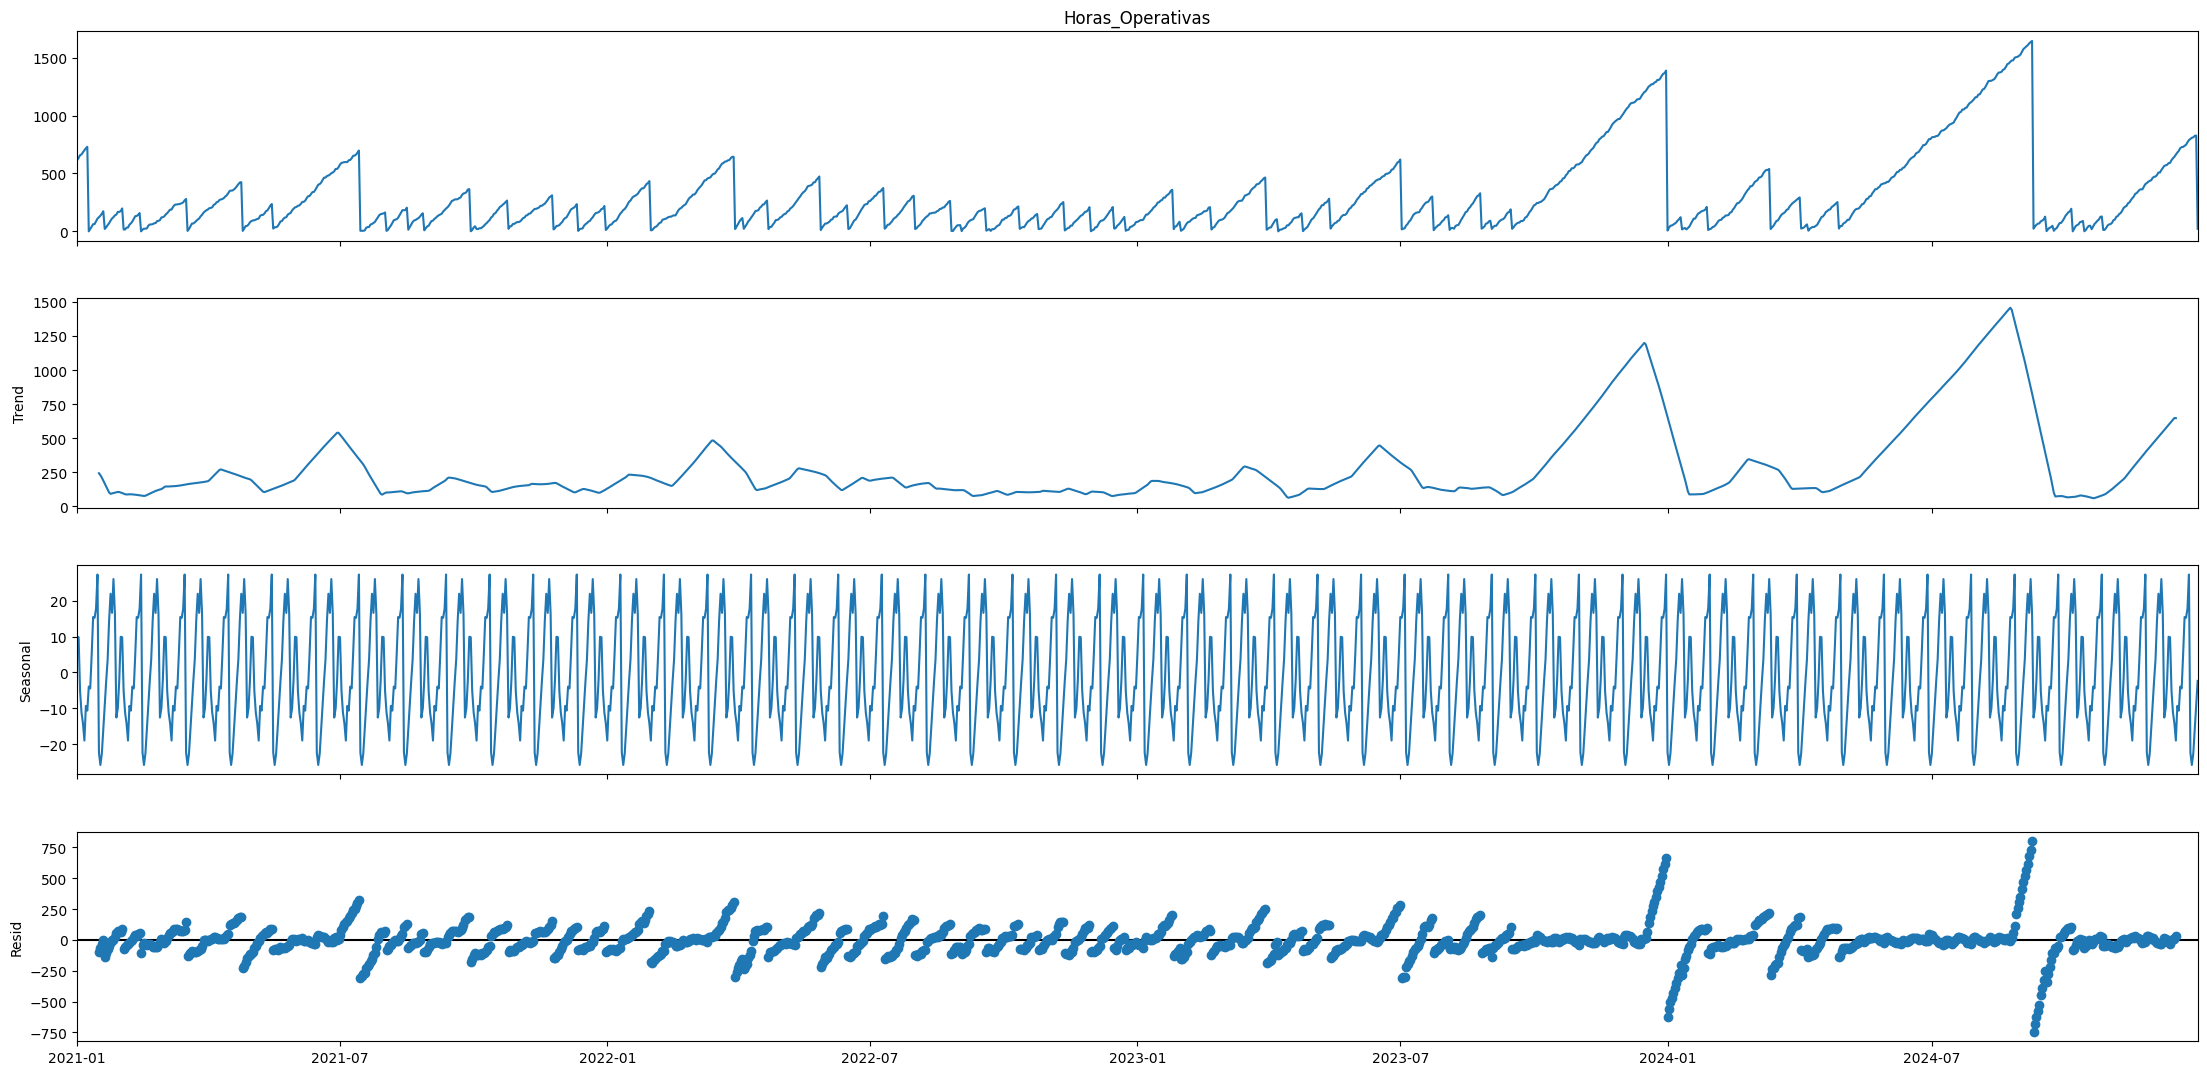

In [57]:
# --- 3. Descomposición aditiva (periodo 7 días) ---
decomp = seasonal_decompose(serie, model='additive', period=30)
fig = decomp.plot()
fig.set_size_inches(25, 12)
plt.show()

En esta segunda descomposición vemos varias diferencias respecto a la primera:

1. **Serie original**  
   - Sigue habiendo los característicos “dientes de sierra” (acumulación de horas, pico y reseteo), pero ahora el reinicio al mantenimiento (huecos llenados con ceros) es más pronunciado y frecuente.  

2. **Tendencia**  
   - El suavizado de la tendencia muestra secciones más planas y otras de subida más gradual. Esto se debe a que, al rellenar con ceros los días sin registro, muchos tramos intermedios son constantes antes de que vuelva a crecer la cuenta acumulada.  
   - Los picos máximos (previos a cada reseteo) siguen aumentando a lo largo del tiempo, pero la curva “entre picos” se está aplanando más a causa de esos días a cero.

3. **Estacionalidad**  
   - Aquí el componente semanal tiene una amplitud de ±25 h en lugar de ±5 h. Eso indica que el proceso de “rellenar a cero” y la cadencia de uso mantiene un ciclo prácticamente semanal con variaciones mayores: quizá los fines de semana o determinados días laborables efectivamente el equipo no opera, creando un patrón más acusado.  
   - La forma sinusoidal de este componente es muy clara, lo que confirma un ciclo casi rígido de siete días.

4. **Residuales**  
   - Se aprecian outliers negativos muy marcados (los reseteos a cero), y algunos picos positivos “flotantes” justo antes del mantenimiento.  
   - Ya no hay tantos puntos dispersos alrededor de cero (como en la descomposición previa), porque gran parte de la variabilidad sistemática (ceros semanales) ha sido absorbida por la estacionalidad.

---

### Implicaciones

- **El relleno con ceros** ha reforzado el componente estacional semanal, porque introduce ceros repetidos en el mismo día de la semana.  
- **El modelo** debería incluir esa estacionalidad claramente (p. ej. SARIMAX con periodo 7) y manejar explícitamente los outliers de mantenimiento (intervenciones o variables dummy) para no distorsionar la estimación de los coeficientes.  
- **La tendencia** suavizada revela que, fuera del pico final antes del mantenimiento, el equipo opera a un ritmo relativamente constante poco antes de cada parada, lo cual podría modelarse también con funciones de base o splines.

En definitiva, esta segunda descomposición confirma que el “relleno a cero” diario crea un fuerte ciclo semanal que hay que capturar en el modelo, y que los reseteos por mantenimiento deben tratarse como eventos de intervención para lograr pronósticos más ajustados.


In [50]:
# --- 4. Búsqueda sencilla de orden SARIMAX por AIC ---
best_aic = float('inf')
best_order = None
best_seasonal = None
for p in range(2):
    for d in range(2):
        for q in range(2):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            m = SARIMAX(
                                serie,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)
                            if m.aic < best_aic:
                                best_aic = m.aic
                                best_order = (p, d, q)
                                best_seasonal = (P, D, Q, 7)
                        except:
                            continue

print(f"Mejor orden: {best_order}, estacional: {best_seasonal}, AIC: {best_aic:.1f}")

Mejor orden: (1, 1, 1), estacional: (0, 1, 1, 7), AIC: 16877.4


Ese resultado te está diciendo dos cosas:

1. **Órdenes del modelo SARIMAX**  
   - **No estacional (p, d, q) = (1, 1, 1)**  
     - p = 1: incluye un término autorregresivo de orden 1 (AR(1)), es decir, la serie diferenciada depende de su valor inmediatamente anterior.  
     - d = 1: se ha aplicado una diferenciación de primer orden para estabilizar la media (eliminar tendencia).  
     - q = 1: incluye un término de media móvil de orden 1 (MA(1)), que corrige los errores de predicción del paso anterior.

   - **Estacional (P, D, Q, s) = (0, 1, 1, 7)**  
     - P = 0: no hay término autorregresivo estacional.  
     - D = 1: se ha aplicado una diferenciación estacional de orden 1 (para eliminar tendencia a nivel de ciclo semanal).  
     - Q = 1: hay un término de media móvil estacional de orden 1 (captura la dependencia del error de hace una semana).  
     - s = 7: la periodicidad estacional es de 7 días (captura el ciclo semanal).

2. **AIC = 16877.4**  
   - El **Akaike Information Criterion** (AIC) es una métrica que combina la bondad de ajuste del modelo con una penalización por complejidad (número de parámetros).  
   - Un **AIC más bajo** indica un modelo preferible (mejor balance entre ajuste y parsimonia).  
   - Ese valor en sí no es “bueno” o “malo” de forma absoluta, pero te sirve para **comparar** varios modelos: elegirás el que tenga el AIC más bajo.

En resumen, este SARIMAX(1,1,1)×(0,1,1,7) ha resultado óptimo (en tu búsqueda) para capturar tanto la dinámica a corto plazo (ARMA) como el ciclo semanal, y su AIC es la medida que confirma que es el más parsimonioso de los que evaluaste.


In [51]:
# --- 5. Ajuste del modelo final ---
model = SARIMAX(
    serie,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                  Horas_Operativas   No. Observations:                 1461
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -8434.689
Date:                           Thu, 24 Apr 2025   AIC                          16877.379
Time:                                   19:17:25   BIC                          16898.479
Sample:                               01-01-2021   HQIC                         16885.254
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9608      0.016     59.438      0.000       0.929       0.992
ma.L1         -1.0000      4.211     -0.237

Este reporte del modelo SARIMAX(1,1,1)×(0,1,1,7) contiene tres bloques clave: coeficientes, criterios de información y diagnósticos de residuos. Te los desgloso:

---

### 1. Coeficientes del modelo

| Parámetro  | Valor    | Error std | z-score | p-value | IC 95 %             | Interpretación                            |
|------------|----------|-----------|---------|---------|---------------------|-------------------------------------------|
| **ar.L1**  | 0.9608   | 0.016     | 59.438  | 0.000   | [0.929, 0.992]      | Muy significativo. La serie diferenciada depende fuertemente de su valor previo. |
| **ma.L1**  | −1.0000  | 4.211     | −0.237  | 0.812   | [−9.253, 7.253]     | No significativo. Este término MA(1) quizá no aporte. |
| **ma.S.L7**| −0.9903  | 0.016     | −62.531 | 0.000   | [−1.021, −0.959]    | Muy significativo. Captura la dependencia del error a 7 días (ciclo semanal). |
| **sigma2** | 6769.3   | 2.85e+04  | 0.238   | 0.812   | [−4.9e+04, 6.26e+04]| Varianza del ruido; alta, lo que refleja residuos muy dispersos. |

- Un **coeficiente AR(1)≈0.96** indica fuerte persistencia.
- El **MA estacional** es también casi −1, confirmando que el ciclo semanal es esencial.
- El **MA no estacional** resulta irrelevante (p≈0.8), podrías probar un modelo sin él.

---

### 2. Criterios de información

- **AIC = 16877.38**, **BIC = 16898.48**, **HQIC = 16885.25**  
  Miden el balance ajuste-complejidad. Para comparar varios modelos entre sí, el que tenga el **AIC/BIC más bajo** será el preferido.

---

### 3. Diagnósticos de residuos

| Test                               | Estadístico | p-value | Interpretación                                    |
|------------------------------------|-------------|---------|---------------------------------------------------|
| **Ljung–Box (lag 1) Q = 0.17**     | p = 0.68    | >0.05   | No hay autocorrelación remanente significativa.   |
| **Jarque–Bera (JB)** = 1 509 673   | p ≈ 0.00    | <0.05   | ¡Residuos NO son normales! Colas muy pesadas.    |
| **Heterocedasticity (H = 2.69)**   | p = 0.00    | <0.05   | Varianza no constante en el tiempo.              |

- **Sin autocorrelación**: el modelo captura bien la dependencia serial.
- **No normalidad** (altísima kurtosis) y **heterocedasticidad** indican outliers (reseteos por mantenimiento) y varianza cambiante.

---

## Conclusiones y siguientes pasos

1. **Simplificar**: elimina el término MA(1) y compara AIC; podrías ganar parsimonia.  
2. **Modelar intervenciones**: incorpora dummies para los días de mantenimiento (“reseteos”) y así rebajar los outliers.  
3. **Heterocedasticidad**: si es relevante, considera un modelo ARIMA–GARCH para capturar la varianza variable.  

Con esto afinarás el modelo para que sea más estable y interpretable.


In [62]:
# --- 6. Pronóstico a 15 días ---
n_periods = 30
pred = model.get_prediction(start=len(serie), end=len(serie) + n_periods - 1)
fc = pred.predicted_mean
ci = pred.conf_int()
index_fc = pd.date_range(start=serie.index[-1] + pd.Timedelta(days=1),
                         periods=n_periods, freq='D')
df_forecast = pd.DataFrame({
    'forecast': fc.values,
    'lower_ci': ci.iloc[:, 0].values,
    'upper_ci': ci.iloc[:, 1].values
}, index=index_fc)

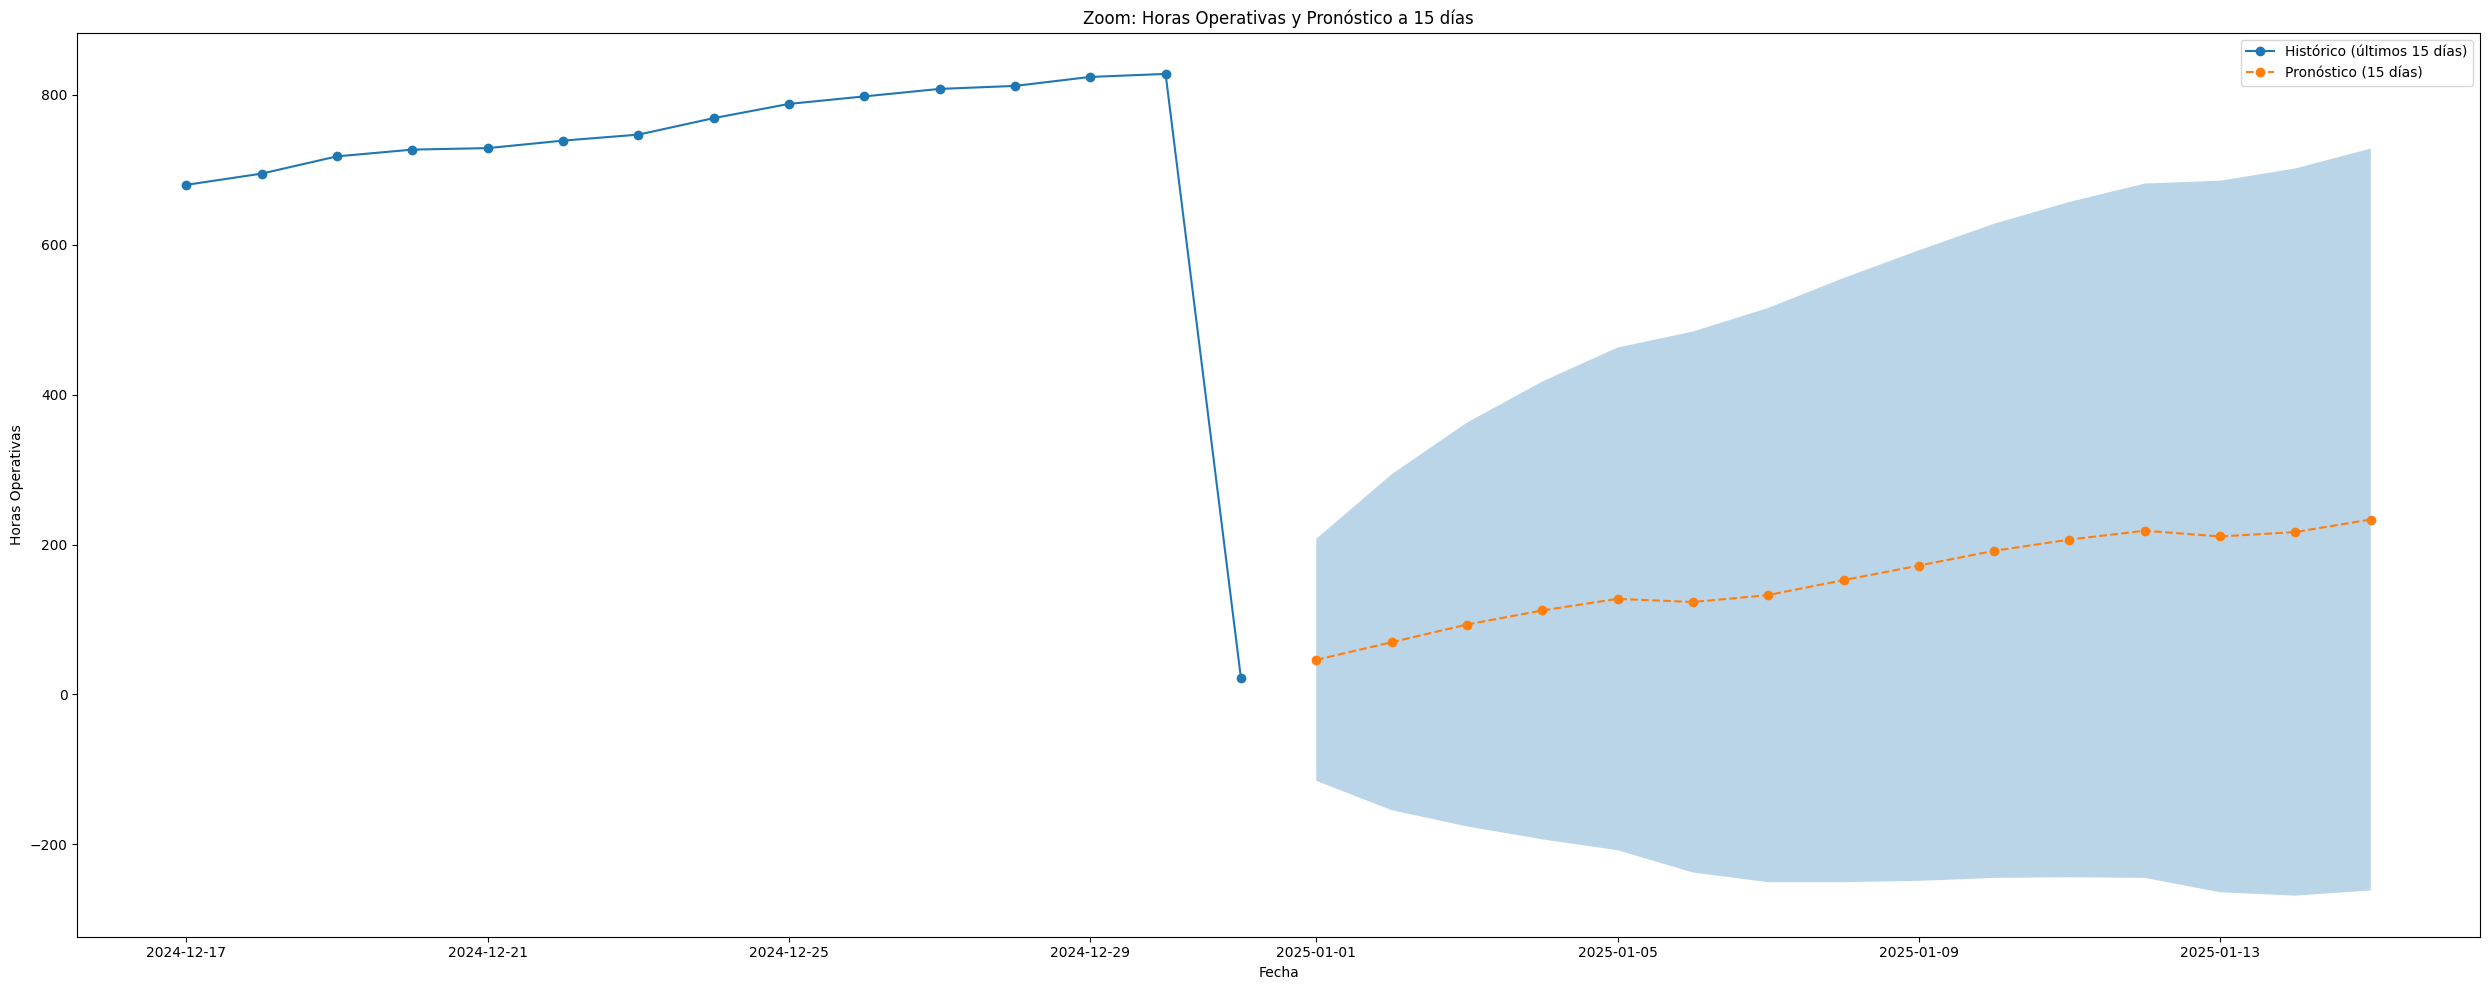

In [61]:
# --- 7. Visualización con zoom en los últimos 30 días + pronóstico ---
window_days = 15
hist_zoom = serie.iloc[-window_days:]

plt.figure(figsize=(25, 10))
plt.plot(hist_zoom.index, hist_zoom, marker='o',
         label=f'Histórico (últimos {window_days} días)')
plt.plot(df_forecast.index, df_forecast['forecast'],
         marker='o', linestyle='--', label='Pronóstico (15 días)')
plt.fill_between(df_forecast.index,
                 df_forecast['lower_ci'], df_forecast['upper_ci'],
                 alpha=0.3)
plt.title('Zoom: Horas Operativas y Pronóstico a 15 días')
plt.xlabel('Fecha')
plt.ylabel('Horas Operativas')
plt.legend()
plt.tight_layout()
plt.show()

En este zoom de los últimos 15 días del histórico y los 15 días de pronóstico se aprecia:

1. **Punto de partida tras mantenimiento**  
   - El día 2024-12-30 la serie cae prácticamente a cero (reinicio tras correctivo).  
   - El pronóstico para 2025-01-01 arranca en torno a 45 h, que es ya un poco más alto que cero: el modelo “espera” un reinicio incompleto y algo de operación desde el día 1.

2. **Pendiente del pronóstico vs. histórico**  
   - En el histórico (azul sólido) la acumulación diaria tras el reinicio es muy pronunciada: pasa de ~20 h a casi 850 h en 15 días.  
   - El pronóstico (naranja punteado) predice un incremento mucho más suave, alcanzando solo ~230 h al día 15.  
   - Esto indica que el modelo subestima la velocidad real de acumulación de horas operativas, probablemente porque los picos históricos combinan tendencia creciente + efecto de evento “intervención” que el modelo no captura plenamente.

3. **Intervalo de confianza**  
   - El sombreado (±95 % CI) crece rápidamente: de ±200 h al inicio a más de ±500 h al final.  
   - Esa amplitud refleja la **alta varianza residual** (σ² grande) y la **incertidumbre creciente** cuando proyectas tan lejos en un proceso con outliers por mantenimiento.

4. **Diagnóstico rápido**  
   - **Subestimación de la pendiente** sugiere falta de variables exógenas (dummies de mantenimiento) o un componente de tendencia más fuerte.  
   - **Anchas bandas de CI** apuntan a heterocedasticidad y outliers: un modelo ARIMA–GARCH o intervención explícita (días de parada) podría reducir esa incerteza.

---

**En resumen**, el modelo captura el reinicio y la dirección general (incremento tras cero), pero **subestima la tasa de acumulación** y arroja **muy alta incertidumbre**. Para mejorar:

- Añadir dummies que marquen los días de mantenimiento.  
- Incorporar un componente de tendencia más flexible (p. ej. splines, regresión lineal exógena).  
- Considerar un modelo que maneje heterocedasticidad (GARCH) o outliers robustos.


In [54]:
# --- 8. Mostrar la tabla de pronóstico en Azure ML ---
display(df_forecast)


,forecast,lower_ci,upper_ci
2025-01-01,46.207818,-115.210518,207.626153
2025-01-02,69.716491,-154.315311,293.748294
2025-01-03,93.339903,-176.006840,362.686647
2025-01-04,112.137573,-193.251308,417.526453
2025-01-05,127.575672,-207.771091,462.922434
2025-01-06,123.390745,-237.506627,484.288118
2025-01-07,132.655953,-250.405526,515.717431
2025-01-08,152.600456,-250.421178,555.622090
2025-01-09,172.013066,-248.669952,592.696085
2025-01-10,191.701104,-244.721576,628.123785
